In [53]:
import os
import argparse
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from PIL import Image
from matplotlib import cm
import random
import sys

eps = sys.float_info.epsilon

In [36]:
populations_df = pd.read_csv("../out/populations.csv")
adjacency_df = pd.read_csv("../out/adjacency.csv")

In [37]:
pop_sizes = populations_df[["Generation", "Population"]].groupby("Generation", as_index=False).sum()

In [38]:
pop_sizes["Generation"].max()

582

In [87]:
identities = populations_df["Identity"].unique()
cols = cm.rainbow(np.linspace(0, 1, len(identities))).tolist()
random.shuffle(cols)
col_map = {identities[i]: np.array(list(map(lambda x: (int)(x * 255), cols[i]))) for i in range(len(identities))}

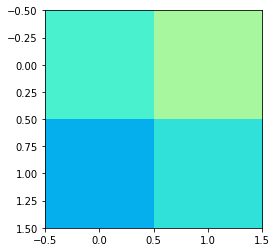

In [40]:
x_len = pop_sizes["Generation"].max() + 1
y_len = pop_sizes["Population"].max()
scale_down = x_len / y_len

pixels = [
   [col_map[identities[0]], col_map[identities[1]]],
   [col_map[identities[2]], col_map[identities[3]]]
]

# Convert the pixels into an array using numpy
array = np.array(pixels, dtype=np.uint8)
# Use PIL to create an image from the new array of pixels
new_image = Image.fromarray(array)
plt.imshow(new_image)

In [106]:
def line_from_data(px_row, width):
    result = []
    pop_total = sum(row_it[0] for row_it in px_row)
    for i in range(len(px_row)):
        px_row[i][0] *= width / pop_total
    contr = 1.0
    index = 0
    new_px = np.array([0.0, 0.0, 0.0, 0.0])
    while index < len(px_row):
        if px_row[index][0] >= eps:
            factor = contr if px_row[index][0] >= contr else px_row[index][0]
            px_row[index][0] -= factor
            contr -= factor
            new_px += px_row[index][1] * factor
            if contr < eps:
                contr = 1.0
                result.append(new_px)
                new_px = np.array([0.0, 0.0, 0.0, 0.0])
        else:
            index += 1
    if len(result) < width:
        result.append(new_px)
    return result

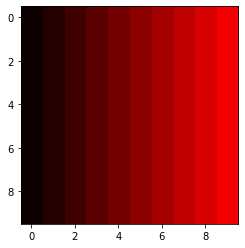

In [113]:
px_row = [[10, np.array([i,0,0,255])] for i in range(256)]
test_px = line_from_data(px_row, 10)
array = np.array([test_px] * 10, dtype=np.uint8)
# Test img
new_image = Image.fromarray(array)
plt.imshow(new_image)

In [111]:
width = x_len
img_pixels = []
for i in range(0, x_len):
    gen = populations_df[populations_df["Generation"] == i]
    pixel_row = []
    total_pop = gen["Population"].sum()
    for index, row in gen.iterrows():
        col = col_map[row["Identity"]]
        pop = row["Population"]
        pixel_row.append([pop, col])
    line_px = line_from_data(pixel_row, width)
    img_pixels.append(line_px)

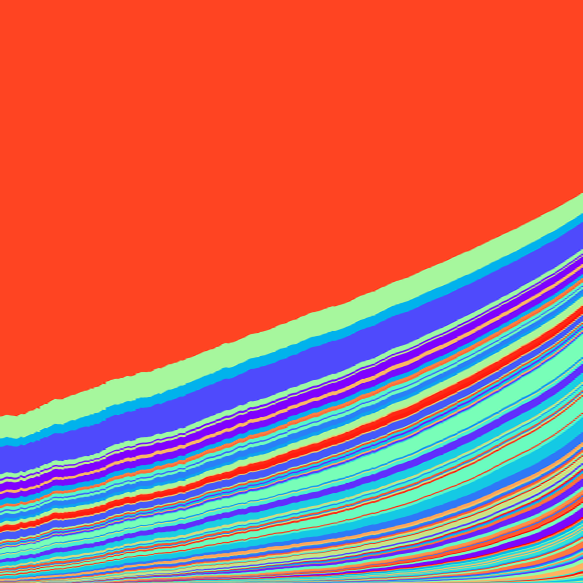

In [112]:
array = np.array(img_pixels, dtype=np.uint8)
new_image = Image.fromarray(array).rotate(-90).transpose(Image.FLIP_LEFT_RIGHT)
size = new_image.size
cropped = new_image.crop((size[0] // 2, 0, size[0], size[1]))
cropped.resize(size, Image.ANTIALIAS)

In [162]:
array.shape

(914, 914, 4)

In [165]:
populations_df[populations_df["Generation"] == 100]["Population"].sum()

336

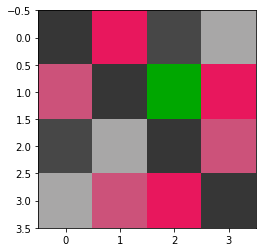

In [268]:
populations_df[populations_df["Generation"] == populations_df["Generation"].max()].sort_values(by = "Population", ascending=False)

,Generation,Identity,Population
388,273,569,120539
596,273,750,69880
664,273,828,36374
630,273,824,35648
448,273,609,34263
...,...,...,...
542,273,731,1939
486,273,666,1848
1207,273,1339,1835
957,273,1145,1814


0.0010218821414356438